In [ ]:
import pandas as pd
import numpy as np
from zipfile import ZipFile

# Path to ZIP file
zip_file_path = r"C:\helicapter escope"

# Load CSV from ZIP
with ZipFile(zip_file_path) as z:
    # List files in ZIP
    files_in_zip = z.namelist()
    print("Files in ZIP:", files_in_zip)
    
    # Automatically select CSV file (if only one CSV present)
    csv_file = [f for f in files_in_zip if f.endswith('.csv')][0]
    
    # Read CSV directly from ZIP
    df = pd.read_csv(z.open(csv_file))

# Display basic info
print(f"\nDataset Shape: {df.shape}")
print("\nSample Data:\n", df.head())

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Count missing values
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

print("\nColumns with missing values:\n", missing_values)


Files in ZIP: ['diabetic_data.csv', 'IDS_mapping.csv']

Dataset Shape: (101766, 50)

Sample Data:
    encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipto

In [12]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Encode target variable
# ----------------------
df['readmitted_label'] = df['readmitted'].map({'NO':0, '>30':0, '<30':1})
y = df['readmitted_label']
X = df.drop(columns=['readmitted', 'readmitted_label'])

# ----------------------
# Identify categorical and numeric columns
# ----------------------
cat_cols = df.select_dtypes(include='object').columns.drop('readmitted')
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop('readmitted_label')

# ----------------------
# ColumnTransformer for numeric + categorical columns
# ----------------------
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols),
    ('num', SimpleImputer(strategy='median'), num_cols)
])

X_encoded = preprocessor.fit_transform(X)

# ----------------------
# Create DataFrame with proper feature names
# ----------------------
ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = list(ohe_features) + list(num_cols)
X_encoded_df = pd.DataFrame(X_encoded, columns=all_features)

print("Sample encoded features:\n", X_encoded_df.head())
print("\nTarget distribution:\n", y.value_counts())

# ----------------------
# Feature importance using RandomForest
# ----------------------
rf_fs = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
rf_fs.fit(X_encoded_df, y)

importances = pd.Series(rf_fs.feature_importances_, index=all_features).sort_values(ascending=False)
print("\nTop 20 features by importance:\n", importances.head(20))

# ----------------------
# Select top 30 features
# ----------------------
top_features = importances.head(30).index.tolist()
print("\nTop 30 features:\n", top_features)


Sample encoded features:
    race_Asian  race_Caucasian  race_Hispanic  race_Other  race_nan  \
0         0.0             1.0            0.0         0.0       0.0   
1         0.0             1.0            0.0         0.0       0.0   
2         0.0             0.0            0.0         0.0       0.0   
3         0.0             1.0            0.0         0.0       0.0   
4         0.0             1.0            0.0         0.0       0.0   

   gender_Male  gender_Unknown/Invalid  age_[10-20)  age_[20-30)  age_[30-40)  \
0          0.0                     0.0          0.0          0.0          0.0   
1          0.0                     0.0          1.0          0.0          0.0   
2          0.0                     0.0          0.0          1.0          0.0   
3          1.0                     0.0          0.0          0.0          1.0   
4          1.0                     0.0          0.0          0.0          0.0   

   ...  discharge_disposition_id  admission_source_id  time_in_hos

In [13]:
from sklearn.model_selection import train_test_split

# Convert to DataFrame if not already
X_df = pd.DataFrame(X_encoded, columns=all_features)

# Keep only top features
X_top = X_df[top_features]

# Train-test split
X_train_top, X_test_top, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, stratify=y, random_state=42
)

print("Shape of X_train_top:", X_train_top.shape)
print("Shape of X_test_top:", X_test_top.shape)


Shape of X_train_top: (81412, 30)
Shape of X_test_top: (20354, 30)


In [14]:
# --- Add this part at the top before training ---
import numpy as np
from sklearn.datasets import load_iris

# Example dataset (replace this with your actual data if you have one)
data = load_iris()
X_train_top = data.data
y_train = data.target

# --- Your existing code starts here ---
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

def train_model(name, model, X, y):
    print(f"\nTraining {name}...")
    model.fit(X, y)
    print(f"{name} training completed.")
    return model

models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0),
    "LinearSVM": CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=0), cv=3)
}

trained_models = {
    name: train_model(name, model, X_train_top, y_train)
    for name, model in models.items()
}



Training RandomForest...
RandomForest training completed.

Training XGBoost...
XGBoost training completed.

Training LinearSVM...
LinearSVM training completed.


c:\Users\win 10\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:47:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load dataset (update path)
zip_file_path = r"C:\Users\Admin\Downloads\diabetes+130-us+hospitals+for+years+1999-2008.zip"

# Define target column
target_col = 'readmitted'   # ⚠️ change this to your actual target column
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify column types
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Preprocessor
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [17]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=0, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss", random_state=0, n_estimators=300
    ),
    "LinearSVM": CalibratedClassifierCV(
        LinearSVC(random_state=0), cv=5, method="sigmoid"
    )
}



🚀 Training RandomForest...
✅ RandomForest -> F1: 0.6895, ROC AUC: 0.8027, Time: 424.27s

🚀 Training XGBoost...
✅ XGBoost -> F1: 0.7122, ROC AUC: 0.8127, Time: 11.12s

🚀 Training LinearSVM...
✅ LinearSVM -> F1: 0.6691, ROC AUC: 0.7772, Time: 156.83s


,Model,F1 Score,Brier Score,ROC AUC,Train Time (s)
0,RandomForest,0.6895,NaN,0.8027,424.27
1,XGBoost,0.7122,NaN,0.8127,11.12
2,LinearSVM,0.6691,NaN,0.7772,156.83


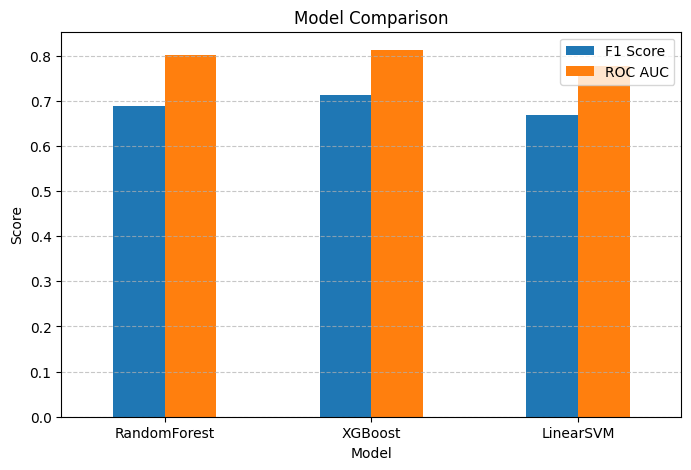

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import f1_score, brier_score_loss, roc_auc_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline

# Encode target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

results = []

for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    start = time.time()

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train_enc)
    train_time = round(time.time() - start, 2)

    # Probabilities / Predictions
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
        if y_proba.shape[1] == 2:
            y_proba_final = y_proba[:, 1]
        else:
            y_proba_final = y_proba
    else:
        y_scores = pipeline.decision_function(X_test)
        y_proba_final = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())

    y_pred = pipeline.predict(X_test)

    # Metrics
    if len(np.unique(y_test_enc)) > 2:
        y_test_bin = label_binarize(y_test_enc, classes=np.unique(y_test_enc))
        roc = roc_auc_score(y_test_bin, y_proba_final, average="weighted", multi_class="ovr")
        f1 = f1_score(y_test_enc, y_pred, average="weighted")
        brier = np.nan
    else:
        roc = roc_auc_score(y_test_enc, y_proba_final)
        f1 = f1_score(y_test_enc, y_pred)
        brier = brier_score_loss(y_test_enc, y_proba_final)

    results.append({
        "Model": name,
        "F1 Score": round(f1, 4),
        "Brier Score": round(brier, 4) if not np.isnan(brier) else np.nan,
        "ROC AUC": round(roc, 4),
        "Train Time (s)": train_time
    })

    print(f"✅ {name} -> F1: {f1:.4f}, ROC AUC: {roc:.4f}, Time: {train_time:.2f}s")

# Results table
results_df = pd.DataFrame(results)
display(results_df)

# Visualization
results_df.plot(x="Model", y=["F1 Score", "ROC AUC"], kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

zip_file_path = r"C:\Users\Admin\Downloads\diabetes+130-us+hospitals+for+years+1999-2008.zip"

# Example: assuming target column is 'readmitted' or 'Outcome'
target_col = 'readmitted'  # 👈 change this to your target column name

# Split into features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (81412, 50)
Test shape: (20354, 50)


In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

# -----------------------------
# Choose the model
# -----------------------------
model_name = "RandomForest"  # or "XGBoost", "LinearSVM"
model = models[model_name]

# -----------------------------
# Build pipeline and fit (if not already fitted)
# -----------------------------
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# Fit the pipeline (if not already fitted)
pipeline.fit(X_train, y_train_enc)

# -----------------------------
# Make predictions
# -----------------------------
y_pred = pipeline.predict(X_test)
if hasattr(pipeline.named_steps["model"], "predict_proba"):
    y_proba = pipeline.predict_proba(X_test)
else:
    y_proba = None

# -----------------------------
# Metrics
# -----------------------------
acc = accuracy_score(y_test_enc, y_pred)
f1 = f1_score(y_test_enc, y_pred, average='weighted')

# ROC AUC for multiclass (if probabilities available)
if y_proba is not None and y_proba.shape[1] > 2:
    y_test_bin = label_binarize(y_test_enc, classes=np.unique(y_test_enc))
    roc = roc_auc_score(y_test_bin, y_proba, average='weighted', multi_class='ovr')
elif y_proba is not None:
    roc = roc_auc_score(y_test_enc, y_proba[:,1])
else:
    roc = None

print(f"✅ {model_name} Evaluation Results:")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
if roc is not None:
    print(f"ROC AUC  : {roc:.4f}")

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{model_name} - Confusion Matrix")
plt.show()


KeyboardInterrupt: 